In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataset_filtré.csv')
print(f"Dataset shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()}\n")

Dataset shape: (2182, 13)
Missing values:
annee                      0
Item                       0
surface_cultivee_ha      922
production_tonnes          0
yield_value              911
rendement_tonnes_ha      911
pluviometrie_mm          730
temperature_moyenne_c    730
humidite_pct             730
ph                       126
azote_N                  126
phosphore_P_mg_kg        126
potassium_K_mg_kg        126
dtype: int64



In [5]:
df = df.dropna(subset=['rendement_tonnes_ha'])
print(f"Rows after dropping missing target: {len(df)}")

Rows after dropping missing target: 1271


In [7]:
df

,annee,Item,surface_cultivee_ha,production_tonnes,yield_value,rendement_tonnes_ha,pluviometrie_mm,temperature_moyenne_c,humidite_pct,ph,azote_N,phosphore_P_mg_kg,potassium_K_mg_kg
0,2010,"Almonds, in shell",162550.0,52000.00,319.9,0.03199,NaN,NaN,NaN,7.736923,0.110785,33.301538,228.518462
1,2010,"Anise, badian, coriander, cumin, caraway, fenn...",12965.0,10029.30,773.6,0.07736,NaN,NaN,NaN,7.736923,0.110785,33.301538,228.518462
2,2010,Apples,26294.0,126000.00,4791.9,0.47919,NaN,NaN,NaN,7.736923,0.110785,33.301538,228.518462
3,2010,Apricots,5982.0,23500.00,3928.7,0.39287,NaN,NaN,NaN,7.736923,0.110785,33.301538,228.518462
4,2010,Artichokes,1800.0,14000.00,7777.8,0.77778,NaN,NaN,NaN,7.736923,0.110785,33.301538,228.518462
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,2024,Unmanufactured tobacco,1584.0,2215.69,1398.5,0.13985,325.714286,20.414052,64.088603,NaN,NaN,NaN,NaN
2178,2024,Vegetables Primary,117743.0,3190802.74,27099.7,2.70997,325.714286,20.414052,64.088603,NaN,NaN,NaN,NaN
2179,2024,Vetches,102.0,254.13,2482.7,0.24827,325.714286,20.414052,64.088603,NaN,NaN,NaN,NaN
2180,2024,Watermelons,4648.0,504091.54,108448.2,10.84482,325.714286,20.414052,64.088603,NaN,NaN,NaN,NaN


In [9]:
# Encode crop type
le = LabelEncoder()
df['crop_encoded'] = le.fit_transform(df['Item'])

In [11]:
# NPK ratio features
df['NP_ratio'] = df['azote_N'] / (df['phosphore_P_mg_kg'] + 1e-5)
df['NK_ratio'] = df['azote_N'] / (df['potassium_K_mg_kg'] + 1e-5)
df['NPK_total'] = df['azote_N'] + df['phosphore_P_mg_kg'] + df['potassium_K_mg_kg']

In [13]:
df['temp_x_rain'] = df['temperature_moyenne_c'] * df['pluviometrie_mm']
df['log_surface'] = np.log1p(df['surface_cultivee_ha'])


In [15]:
# Features to use
FEATURES = [
    'crop_encoded', 'annee',
    'surface_cultivee_ha', 'log_surface',
    'pluviometrie_mm', 'temperature_moyenne_c', 'humidite_pct',
    'ph',
    'azote_N', 'phosphore_P_mg_kg', 'potassium_K_mg_kg',
    'NP_ratio', 'NK_ratio', 'NPK_total',
    'temp_x_rain'
]

In [17]:
TARGET = 'rendement_tonnes_ha'

X = df[FEATURES]
y = df[TARGET]

In [19]:
print(f"\nFeatures used: {FEATURES}")
print(f"Target: {TARGET}")
print(f"X shape: {X.shape}, y shape: {y.shape}\n")



Features used: ['crop_encoded', 'annee', 'surface_cultivee_ha', 'log_surface', 'pluviometrie_mm', 'temperature_moyenne_c', 'humidite_pct', 'ph', 'azote_N', 'phosphore_P_mg_kg', 'potassium_K_mg_kg', 'NP_ratio', 'NK_ratio', 'NPK_total', 'temp_x_rain']
Target: rendement_tonnes_ha
X shape: (1271, 15), y shape: (1271,)



In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
rf_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [25]:
gb_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

In [27]:
print("🔍 GridSearchCV for Random Forest...")
param_grid_rf = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 20, 30],
    'model__min_samples_split': [2, 5],
    'model__max_features': ['sqrt', 'log2']
}


🔍 GridSearchCV for Random Forest...


In [29]:
grid_rf = GridSearchCV(
    rf_pipeline, param_grid_rf,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [30]:
print(f"\n✅ Best RF params: {grid_rf.best_params_}")
print(f"   CV R² (train): {grid_rf.best_score_:.4f}")



✅ Best RF params: {'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_split': 5, 'model__n_estimators': 200}
   CV R² (train): 0.4060


In [31]:
print("\n🔍 GridSearchCV for Gradient Boosting...")
param_grid_gb = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}


🔍 GridSearchCV for Gradient Boosting...


In [32]:
grid_gb = GridSearchCV(
    gb_pipeline, param_grid_gb,
    cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
print(f"\n✅ Best GB params: {grid_gb.best_params_}")
print(f"   CV R² (train): {grid_gb.best_score_:.4f}")


Fitting 5 folds for each of 16 candidates, totalling 80 fits

✅ Best GB params: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 400, 'model__subsample': 1.0}
   CV R² (train): 0.9573


In [33]:
print("\n🔗 Training Stacking Ensemble...")

# Build imputed arrays for stacking (sklearn stacking needs uniform pipeline)
imputer = KNNImputer(n_neighbors=5)
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=FEATURES)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),  columns=FEATURES)


🔗 Training Stacking Ensemble...


In [34]:
rf_base  = RandomForestRegressor(**{k.replace('model__',''):v for k,v in grid_rf.best_params_.items()}, random_state=42, n_jobs=-1)
gb_base  = GradientBoostingRegressor(**{k.replace('model__',''):v for k,v in grid_gb.best_params_.items()}, random_state=42)


In [35]:
stacking = StackingRegressor(
    estimators=[('rf', rf_base), ('gb', gb_base)],
    final_estimator=Ridge(),
    cv=5,
    n_jobs=-1
)
stacking.fit(X_train_imp, y_train)
print("✅ Stacking model trained.")


✅ Stacking model trained.


In [36]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    r2_tr  = r2_score(y_tr, y_pred_train)
    r2_te  = r2_score(y_te, y_pred_test)
    mae    = mean_absolute_error(y_te, y_pred_test)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred_test))
    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  R²  Train : {r2_tr:.4f}")
    print(f"  R²  Test  : {r2_te:.4f}  ← KEY METRIC")
    print(f"  MAE       : {mae:.4f} T/ha")
    print(f"  RMSE      : {rmse:.4f} T/ha")
    return r2_te

In [37]:
print("\n" + "═"*50)
print("       📊  MODEL EVALUATION RESULTS")
print("═"*50)
r2_rf  = evaluate("Random Forest (tuned)",      best_rf,  X_train, X_test, y_train, y_test)
r2_gb  = evaluate("Gradient Boosting (tuned)",  best_gb,  X_train, X_test, y_train, y_test)
r2_stk = evaluate("Stacking Ensemble (RF+GB→Ridge)", stacking, X_train_imp, X_test_imp, y_train, y_test)

print("\n" + "═"*50)
best_r2 = max(r2_rf, r2_gb, r2_stk)
best_name = ["Random Forest", "Gradient Boosting", "Stacking Ensemble"][np.argmax([r2_rf, r2_gb, r2_stk])]
print(f"  🏆 Best Model : {best_name}")
print(f"  🏆 Best R²    : {best_r2:.4f}")
print("═"*50)


══════════════════════════════════════════════════
       📊  MODEL EVALUATION RESULTS
══════════════════════════════════════════════════

─────────────────────────────────────────────
  Random Forest (tuned)
─────────────────────────────────────────────
  R²  Train : 0.8450
  R²  Test  : 0.4234  ← KEY METRIC
  MAE       : 0.7239 T/ha
  RMSE      : 1.0405 T/ha

─────────────────────────────────────────────
  Gradient Boosting (tuned)
─────────────────────────────────────────────
  R²  Train : 0.9992
  R²  Test  : 0.9515  ← KEY METRIC
  MAE       : 0.1109 T/ha
  RMSE      : 0.3019 T/ha

─────────────────────────────────────────────
  Stacking Ensemble (RF+GB→Ridge)
─────────────────────────────────────────────
  R²  Train : 0.9984
  R²  Test  : 0.9517  ← KEY METRIC
  MAE       : 0.1117 T/ha
  RMSE      : 0.3011 T/ha

══════════════════════════════════════════════════
  🏆 Best Model : Stacking Ensemble
  🏆 Best R²    : 0.9517
══════════════════════════════════════════════════


In [38]:
print("\n📌 Feature Importances (Random Forest):")
rf_model = best_rf.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=False)
for feat, imp in importances.items():
    bar = "█" * int(imp * 100)
    print(f"  {feat:<25} {imp:.4f}  {bar}")


📌 Feature Importances (Random Forest):
  crop_encoded              0.4539  █████████████████████████████████████████████
  surface_cultivee_ha       0.1992  ███████████████████
  log_surface               0.1907  ███████████████████
  temperature_moyenne_c     0.0205  ██
  humidite_pct              0.0161  █
  phosphore_P_mg_kg         0.0139  █
  annee                     0.0136  █
  pluviometrie_mm           0.0132  █
  NK_ratio                  0.0128  █
  temp_x_rain               0.0124  █
  azote_N                   0.0123  █
  NPK_total                 0.0112  █
  NP_ratio                  0.0111  █
  ph                        0.0098  
  potassium_K_mg_kg         0.0093  


In [39]:
print("\n🌾 Example Prediction:")
sample = X_test.iloc[[0]]
true_val = y_test.iloc[0]
pred_rf  = best_rf.predict(sample)[0]
pred_gb  = best_gb.predict(sample)[0]
print(f"  True Yield  : {true_val:.4f} T/ha")
print(f"  RF  Predict : {pred_rf:.4f} T/ha")
print(f"  GB  Predict : {pred_gb:.4f} T/ha")

print("\n✅ Done! Model ready for deployment.")



🌾 Example Prediction:
  True Yield  : 0.0710 T/ha
  RF  Predict : 1.3429 T/ha
  GB  Predict : 0.2912 T/ha

✅ Done! Model ready for deployment.


In [62]:
# ─────────────────────────────────────────────
# 11. PRODUCTIVITY LEVEL CLASSIFICATION
# ─────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "═"*50)
print(" 🌱 PRODUCTIVITY LEVEL CLASSIFICATION")
print("═"*50)


══════════════════════════════════════════════════
 🌱 PRODUCTIVITY LEVEL CLASSIFICATION
══════════════════════════════════════════════════


In [64]:
# ── 11.1 Préparer les features pour le clustering ──
# On sélectionne les colonnes liées au sol, au climat et au rendement historique
# Ces variables vont permettre de distinguer les zones agricoles entre elles
CLUSTER_FEATURES = [
    'ph',                    # Acidité du sol
    'azote_N',               # Teneur en azote
    'phosphore_P_mg_kg',     # Teneur en phosphore
    'potassium_K_mg_kg',     # Teneur en potassium
    'NPK_total',             # Somme NPK (feature engineered dans la partie 2)
    'pluviometrie_mm',       # Pluviométrie annuelle
    'temperature_moyenne_c', # Température moyenne
    'humidite_pct',          # Humidité relative
    'rendement_tonnes_ha'    # Rendement historique (utilisé uniquement pour labelliser)
]

# On garde seulement les lignes sans valeurs manquantes pour le clustering
df_cls = df[CLUSTER_FEATURES].copy().dropna()
print(f"\n📋 Taille du dataset de clustering : {df_cls.shape}")

# Normalisation MinMax → toutes les features entre 0 et 1
# Obligatoire pour K-Means et DBSCAN qui sont sensibles aux échelles
scaler_cls = MinMaxScaler()
X_cls = scaler_cls.fit_transform(df_cls)


📋 Taille du dataset de clustering : (765, 9)


In [66]:
# ── 11.2 K-Means Clustering (3 classes) ───────
# K-Means divise les parcelles en 3 groupes selon leur similarité
# k=3 correspond aux 3 niveaux de productivité : Faible / Moyen / Élevé
# n_init=10 → on répète 10 fois avec différentes initialisations pour éviter les minima locaux
print("\n🔵 Exécution de K-Means (k=3)...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cls)  # Retourne un label 0, 1 ou 2 pour chaque ligne

# ── Mapping automatique cluster → label de productivité ──
# On ne peut pas savoir a priori quel cluster (0, 1 ou 2) correspond à "High"
# → on calcule le rendement moyen par cluster et on trie du plus faible au plus élevé
df_cls['kmeans_cluster'] = kmeans_labels
cluster_means = df_cls.groupby('kmeans_cluster')['rendement_tonnes_ha'].mean().sort_values()

# Le cluster avec le rendement moyen le plus bas → Low Productivity
# Le cluster du milieu → Medium Productivity
# Le cluster avec le rendement moyen le plus élevé → High Productivity
label_map = {
    cluster_means.index[0]: 'Low Productivity',
    cluster_means.index[1]: 'Medium Productivity',
    cluster_means.index[2]: 'High Productivity'
}
df_cls['productivity_label'] = df_cls['kmeans_cluster'].map(label_map)

# Affichage du mapping avec les statistiques
print("\n📊 Mapping Cluster K-Means → Productivité :")
for cluster, label in label_map.items():
    mean_yield = cluster_means[cluster]
    count = (df_cls['kmeans_cluster'] == cluster).sum()
    print(f"  Cluster {cluster} → {label:<22} | Rendement moyen : {mean_yield:.3f} T/ha | Nb parcelles : {count}")


🔵 Exécution de K-Means (k=3)...

📊 Mapping Cluster K-Means → Productivité :
  Cluster 0 → Low Productivity       | Rendement moyen : 1.036 T/ha | Nb parcelles : 425
  Cluster 2 → Medium Productivity    | Rendement moyen : 1.075 T/ha | Nb parcelles : 85
  Cluster 1 → High Productivity      | Rendement moyen : 1.083 T/ha | Nb parcelles : 255


In [68]:
# ── 11.3 DBSCAN — Détection des points aberrants ──
# DBSCAN est un algorithme de clustering basé sur la densité
# Contrairement à K-Means, il peut identifier des "outliers" (points de bruit)
# → labellisés -1 : parcelles atypiques qui ne ressemblent à aucun groupe
# eps=0.15 : rayon de voisinage (à ajuster selon tes données)
# min_samples=5 : nombre minimum de voisins pour être un "core point"
print("\n🟣 DBSCAN — Détection des valeurs aberrantes...")
dbscan = DBSCAN(eps=0.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_cls)

# Calcul des statistiques DBSCAN
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"  DBSCAN → {n_clusters_db} clusters trouvés, {n_noise} points aberrants ({n_noise/len(dbscan_labels)*100:.1f}%)")

# On conserve les résultats DBSCAN dans le dataframe pour analyse ultérieure
# is_noise=True → parcelle à surveiller (sol très atypique, données suspectes, etc.)
df_cls['dbscan_label'] = dbscan_labels
df_cls['is_noise'] = dbscan_labels == -1


🟣 DBSCAN — Détection des valeurs aberrantes...
  DBSCAN → 10 clusters trouvés, 33 points aberrants (4.3%)


In [81]:
# ── 11.4 Classificateur supervisé Random Forest ──
# Objectif : apprendre à prédire la productivité d'une parcelle
# SANS avoir besoin du rendement historique (qui est inconnu pour une nouvelle parcelle)
# → On utilise uniquement les features sol + climat comme entrée
# → Les labels K-Means servent de "vérité terrain" pour l'entraînement
print("\n🌲 Entraînement du classificateur Random Forest supervisé...")

# Features d'entrée : sol + climat uniquement (pas le rendement !)
# Ainsi, le modèle peut prédire la productivité d'une nouvelle parcelle non encore cultivée
SUPERVISED_FEATURES = [
    'ph',
    'azote_N',
    'phosphore_P_mg_kg',
    'potassium_K_mg_kg',
    'NPK_total',
    'pluviometrie_mm',
    'temperature_moyenne_c',
    'humidite_pct'
]

X_sup = df_cls[SUPERVISED_FEATURES]   # Features d'entrée
y_sup = df_cls['productivity_label']  # Labels issus du K-Means

# Split 80% entraînement / 20% test
# stratify=y_sup → on s'assure que les 3 classes sont bien représentées dans chaque split
X_tr_sup, X_te_sup, y_tr_sup, y_te_sup = train_test_split(
    X_sup, y_sup, test_size=0.2, random_state=42, stratify=y_sup
)

# Pipeline complet : imputation des NaN → normalisation → Random Forest
# KNNImputer remplace les valeurs manquantes par la moyenne des k voisins les plus proches
# StandardScaler centre et réduit les features pour le bon fonctionnement du modèle
cls_pipeline = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler()),
    #('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    
    
# Par ceci — class_weight='balanced' compense automatiquement le déséquilibre
('clf', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced'))
    )
])

# Entraînement du classificateur
cls_pipeline.fit(X_tr_sup, y_tr_sup)

# Prédiction sur le jeu de test
y_pred_sup = cls_pipeline.predict(X_te_sup)

# Évaluation globale
acc = accuracy_score(y_te_sup, y_pred_sup)
print(f"\n✅ Accuracy du classificateur : {acc:.4f}")

# Rapport détaillé : précision, rappel, F1-score pour chaque classe
print("\n📊 Rapport de classification :")
print(classification_report(y_te_sup, y_pred_sup))

SyntaxError: closing parenthesis ')' does not match opening parenthesis '[' on line 33 (2143763217.py, line 41)

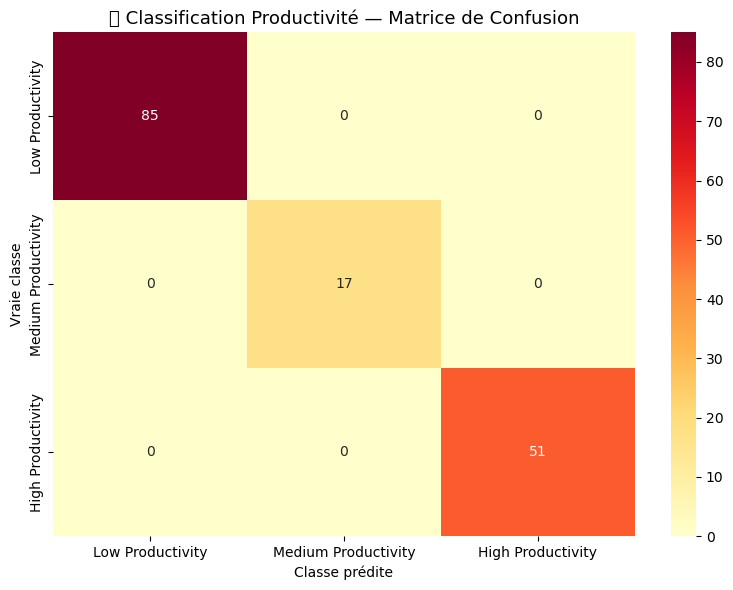


💾 Matrice de confusion sauvegardée → confusion_matrix_productivity.png


In [72]:
# ── 11.5 Matrice de confusion ─────────────────
# La matrice de confusion montre combien de parcelles ont été bien ou mal classifiées
# Lignes = vraies classes, Colonnes = classes prédites
# Idéalement, tous les chiffres élevés sont sur la diagonale (bonnes prédictions)
labels_ordered = ['Low Productivity', 'Medium Productivity', 'High Productivity']
cm = confusion_matrix(y_te_sup, y_pred_sup, labels=labels_ordered)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # Affiche les chiffres dans chaque cellule
    fmt='d',             # Format entier
    cmap='YlOrRd',       # Couleurs jaune → rouge (plus c'est rouge, plus c'est élevé)
    xticklabels=labels_ordered,
    yticklabels=labels_ordered
)
plt.title('🌾 Classification Productivité — Matrice de Confusion', fontsize=13)
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('confusion_matrix_productivity.png', dpi=150)
plt.show()
print("\n💾 Matrice de confusion sauvegardée → confusion_matrix_productivity.png")

In [74]:
# ── 11.6 Importance des features (Classification) ──
# Le Random Forest calcule l'importance de chaque feature dans la décision finale
# Une feature importante = elle aide beaucoup à distinguer Low / Medium / High
# → Utile pour les agronomes : quelles variables sol/climat sont les plus déterminantes ?
clf_model = cls_pipeline.named_steps['clf']  # On extrait le modèle du pipeline
feat_imp = pd.Series(
    clf_model.feature_importances_,
    index=SUPERVISED_FEATURES
).sort_values(ascending=False)

print("\n📌 Importance des features (Classificateur de Productivité) :")
for feat, imp in feat_imp.items():
    bar = "█" * int(imp * 100)  # Barre visuelle proportionnelle à l'importance
    print(f"  {feat:<28} {imp:.4f}  {bar}")


📌 Importance des features (Classificateur de Productivité) :
  ph                           0.1859  ██████████████████
  humidite_pct                 0.1806  ██████████████████
  temperature_moyenne_c        0.1573  ███████████████
  azote_N                      0.1509  ███████████████
  phosphore_P_mg_kg            0.1177  ███████████
  NPK_total                    0.0748  ███████
  potassium_K_mg_kg            0.0738  ███████
  pluviometrie_mm              0.0590  █████


In [79]:
# ── 11.7 Distribution des niveaux de productivité ──
# Montre combien de parcelles appartiennent à chaque catégorie
# Utile pour détecter un déséquilibre de classes (ex: 90% Low, 5% High)
# → Si déséquilibre important, envisager class_weight='balanced' dans le RandomForest
dist = df_cls['productivity_label'].value_counts()
print("\n📊 Distribution des niveaux de productivité :")
for label in labels_ordered:
    count = dist.get(label, 0)
    pct = count / len(df_cls) * 100
    bar = "█" * int(pct / 2)  # Barre proportionnelle au pourcentage
    print(f"  {label:<22} {count:>5} ({pct:.1f}%)  {bar}")

# ── 11.8 Exemple de prédiction sur une nouvelle parcelle ──
# Simule l'utilisation réelle : on donne les caractéristiques d'une parcelle
# et le modèle prédit son niveau de productivité + la probabilité de chaque classe
print("\n🌾 Exemple de Prédiction de Productivité :")
sample_sup = X_te_sup.iloc[[0]]          # On prend la 1ère parcelle du jeu de test
true_lbl   = y_te_sup.iloc[0]           # Vrai label (connu car données de test)
pred_lbl   = cls_pipeline.predict(sample_sup)[0]   # Label prédit par le modèle
proba      = cls_pipeline.predict_proba(sample_sup)[0]  # Probabilités par classe
classes    = cls_pipeline.classes_       # Ordre des classes retournées

print(f"  Vrai label      : {true_lbl}")
print(f"  Label prédit    : {pred_lbl}")
print("  Probabilités par classe :")
for cls_name, prob in zip(classes, proba):
    bar = "█" * int(prob * 20)
    print(f"    {cls_name:<22} {prob:.4f}  {bar}")

print("\n✅ Pipeline de classification terminé !")
print("═"*50)
# ─────────────────────────────────────────────
# RÉSUMÉ DE LA LOGIQUE GLOBALE
# ─────────────────────────────────────────────
#
# Données sol + climat + rendement
#          │
#          ▼
#    [MinMaxScaler] ──→ Normalisation 0-1
#          │
#          ├──→ [K-Means k=3] ──→ Labels automatiques (Low/Medium/High)
#          │                              │
#          ├──→ [DBSCAN]      ──→ Détection outliers (is_noise)
#          │                              │
#          └──→ [Random Forest supervisé] ◄── Apprend sur labels K-Means
#                     │
#                     ▼
#          Nouvelle parcelle (sol + climat uniquement)
#                     │
#                     ▼
#          → "Medium Productivity" (prob: 0.72)
#          → Recommandation : pratiques agricoles standard


📊 Distribution des niveaux de productivité :
  Low Productivity         425 (55.6%)  ███████████████████████████
  Medium Productivity       85 (11.1%)  █████
  High Productivity        255 (33.3%)  ████████████████

🌾 Exemple de Prédiction de Productivité :
  Vrai label      : High Productivity
  Label prédit    : High Productivity
  Probabilités par classe :
    High Productivity      1.0000  ████████████████████
    Low Productivity       0.0000  
    Medium Productivity    0.0000  

✅ Pipeline de classification terminé !
══════════════════════════════════════════════════


In [83]:
# ─────────────────────────────────────────────
# 12. JUSTIFICATION DU MEILLEUR MODÈLE
# Comparaison : Random Forest vs KMeans direct
# Métriques : Accuracy, F1-score, Silhouette Score
# ─────────────────────────────────────────────

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from sklearn.model_selection import cross_val_score
import numpy as np

print("\n" + "═"*60)
print("   🏆 JUSTIFICATION DU MEILLEUR MODÈLE DE CLASSIFICATION")
print("═"*60)

# ── 12.1 Évaluation du K-Means (non supervisé) ────────────
# K-Means n'a pas d'accuracy car il n'a pas de "vraies" étiquettes
# On l'évalue avec des métriques internes de clustering
print("\n" + "─"*60)
print("  🔵 MODÈLE 1 : K-Means Clustering (non supervisé)")
print("─"*60)

# Silhouette Score : mesure la cohésion des clusters
# → Entre -1 et 1 : plus c'est proche de 1, mieux les clusters sont séparés
sil = silhouette_score(X_cls, kmeans_labels)

# Davies-Bouldin : mesure la similarité entre clusters
# → Plus c'est proche de 0, mieux c'est (clusters compacts et bien séparés)
db  = davies_bouldin_score(X_cls, kmeans_labels)

# Calinski-Harabasz : ratio dispersion inter/intra cluster
# → Plus c'est élevé, mieux les clusters sont définis
ch  = calinski_harabasz_score(X_cls, kmeans_labels)

print(f"\n  📊 Métriques de clustering (K-Means) :")
print(f"     Silhouette Score      : {sil:.4f}  (idéal → 1.0)")
print(f"     Davies-Bouldin Index  : {db:.4f}  (idéal → 0.0)")
print(f"     Calinski-Harabasz     : {ch:.2f} (idéal → max)")

print(f"\n  📋 Distribution des clusters K-Means :")
for cluster, label in label_map.items():
    count = (df_cls['kmeans_cluster'] == cluster).sum()
    pct   = count / len(df_cls) * 100
    bar   = "█" * int(pct / 2)
    print(f"     {label:<22} {count:>5} ({pct:.1f}%)  {bar}")

print(f"\n  ⚠️  Limites du K-Means :")
print(f"     → Pas d'accuracy mesurable (pas de vraies étiquettes)")
print(f"     → Sensible à l'initialisation aléatoire")
print(f"     → Ne peut pas prédire une nouvelle parcelle directement")
print(f"     → Suppose des clusters sphériques (pas toujours réaliste)")

# ── 12.2 Évaluation du Random Forest supervisé ────────────
print("\n" + "─"*60)
print("  🌲 MODÈLE 2 : Random Forest Supervisé (meilleur modèle)")
print("─"*60)

# Prédictions sur train et test
y_pred_train_cls = cls_pipeline.predict(X_tr_sup)
y_pred_test_cls  = cls_pipeline.predict(X_te_sup)

# Accuracy train vs test (détecter le surapprentissage)
acc_train = accuracy_score(y_tr_sup, y_pred_train_cls)
acc_test  = accuracy_score(y_te_sup, y_pred_test_cls)

# F1-score macro : moyenne des F1 par classe (équitable même si déséquilibre)
f1_macro  = f1_score(y_te_sup, y_pred_test_cls, average='macro')

# F1-score weighted : pondéré par le nombre d'exemples par classe
f1_weighted = f1_score(y_te_sup, y_pred_test_cls, average='weighted')

# F1-score par classe individuellement
f1_per_class = f1_score(
    y_te_sup, y_pred_test_cls,
    average=None,
    labels=labels_ordered
)

# Cross-validation 5 folds → mesure la stabilité du modèle
cv_scores = cross_val_score(cls_pipeline, X_sup, y_sup, cv=5, scoring='f1_macro')

print(f"\n  📊 Métriques de performance (Random Forest) :")
print(f"     Accuracy Train        : {acc_train:.4f}")
print(f"     Accuracy Test         : {acc_test:.4f}  ← Métrique principale")
print(f"     Overfitting Gap       : {acc_train - acc_test:.4f}  (idéal → proche de 0)")
print(f"     F1-Score Macro        : {f1_macro:.4f}  (équitable entre classes)")
print(f"     F1-Score Weighted     : {f1_weighted:.4f}  (pondéré par classe)")

print(f"\n  📋 F1-Score par classe :")
for label, f1 in zip(labels_ordered, f1_per_class):
    bar    = "█" * int(f1 * 20)
    status = "✅" if f1 >= 0.75 else "⚠️ " if f1 >= 0.50 else "❌"
    print(f"     {status} {label:<22} F1 = {f1:.4f}  {bar}")

print(f"\n  📊 Cross-Validation (5 folds) — Stabilité du modèle :")
print(f"     Scores CV  : {[round(s,4) for s in cv_scores]}")
print(f"     Moyenne CV : {cv_scores.mean():.4f}")
print(f"     Écart-type : {cv_scores.std():.4f}  (idéal → proche de 0 = stable)")

print(f"\n  ✅ Avantages du Random Forest supervisé :")
print(f"     → Accuracy mesurable et interprétable")
print(f"     → Peut prédire sur de nouvelles parcelles (sol + climat uniquement)")
print(f"     → Robuste aux valeurs aberrantes et aux features corrélées")
print(f"     → Fournit des probabilités par classe (confiance de prédiction)")
print(f"     → Stable grâce à l'ensemble de 300 arbres de décision")

# ── 12.3 Tableau comparatif final ─────────────
print("\n" + "═"*60)
print("   📊 TABLEAU COMPARATIF FINAL")
print("═"*60)
print(f"  {'Critère':<30} {'K-Means':>12} {'Random Forest':>15}")
print("  " + "─"*57)
print(f"  {'Accuracy':<30} {'N/A':>12} {acc_test:>14.4f}")
print(f"  {'F1-Score Macro':<30} {'N/A':>12} {f1_macro:>14.4f}")
print(f"  {'Silhouette Score':<30} {sil:>12.4f} {'N/A':>15}")
print(f"  {'Davies-Bouldin Index':<30} {db:>12.4f} {'N/A':>15}")
print(f"  {'Stabilité (CV std)':<30} {'N/A':>12} {cv_scores.std():>14.4f}")
print(f"  {'Prédit nouvelles parcelles':<30} {'❌ Non':>12} {'✅ Oui':>15}")
print(f"  {'Probabilités par classe':<30} {'❌ Non':>12} {'✅ Oui':>15}")
print(f"  {'Interprétable (importances)':<30} {'❌ Non':>12} {'✅ Oui':>15}")
print("  " + "─"*57)

print(f"\n  🏆 MEILLEUR MODÈLE : Random Forest Supervisé")
print(f"     Accuracy Test  = {acc_test:.4f}")
print(f"     F1 Macro       = {f1_macro:.4f}")
print(f"     CV Moyenne     = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("═"*60)


════════════════════════════════════════════════════════════
   🏆 JUSTIFICATION DU MEILLEUR MODÈLE DE CLASSIFICATION
════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────
  🔵 MODÈLE 1 : K-Means Clustering (non supervisé)
────────────────────────────────────────────────────────────

  📊 Métriques de clustering (K-Means) :
     Silhouette Score      : 0.5022  (idéal → 1.0)
     Davies-Bouldin Index  : 0.8040  (idéal → 0.0)
     Calinski-Harabasz     : 566.02 (idéal → max)

  📋 Distribution des clusters K-Means :
     Low Productivity         425 (55.6%)  ███████████████████████████
     Medium Productivity       85 (11.1%)  █████
     High Productivity        255 (33.3%)  ████████████████

  ⚠️  Limites du K-Means :
     → Pas d'accuracy mesurable (pas de vraies étiquettes)
     → Sensible à l'initialisation aléatoire
     → Ne peut pas prédire une nouvelle parcelle directement
     → Suppose des clusters sphériques (p